In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [5]:
df = pd.read_csv("iriss.csv")

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
y = df['species']

In [8]:
x = df.drop(columns='species')

In [10]:
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(x_train, y_train)
y_pred_default = rf_default.predict(x_test)
default_accuracy = accuracy_score(y_test, y_pred_default)

print("Accuracy with 10 trees:", default_accuracy)

Accuracy with 10 trees: 1.0


In [24]:
tree_range = range(1, 101)  
scores = []

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)
    scores.append(accuracy_score(y_test, y_pred))

In [27]:
best_n = tree_range[np.argmax(scores)]
best_score = max(scores)

print("\nBest Accuracy:", best_score)
print("Best number of trees:", best_n)


Best Accuracy: 1.0
Best number of trees: 1


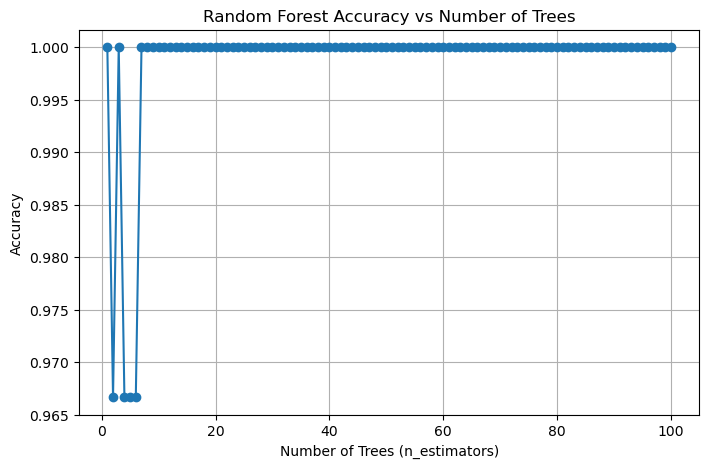

In [28]:
plt.figure(figsize=(8,5))
plt.plot(tree_range, scores, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid()
plt.show()